In [37]:
import time

## Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from datetime import datetime
import os

## Load other scripts
from modelScripts.prepAcousticData import prepAcousticData
from modelScripts.pca import pca
from modelScripts.spectrogram import spectrogram
from modelScripts.hardThreshold import hard_threshold
from modelScripts.HMM import performHMM
from modelScripts.permuteClass import permuteSpecies

# Reading Data

In [2]:
## Zoom in the current directory
curWorkingDir = os.getcwd()
print("Current working directory: ", curWorkingDir)

Current working directory:  c:\Users\86139\Desktop\FishTetherExperiment\Analysis_Scripts


In [ ]:
os.chdir("../")
today = datetime.today().strftime('%Y-%m-%d')
newResultDir = f"Output\\{today}-Results"
if not os.path.exists(newResultDir):
    os.makedirs(newResultDir, exist_ok=True)
    print(f"New directory created: {newResultDir}")

New directory created: Output\2025-04-18-Results


In [6]:
# Read and clean the processed data
readingStart = time.time()
dataPath = "C:\\Users\\86139\\Desktop\\FishTetherExperiment\\ProcessedData"
inputPath = os.path.join(dataPath, "processed_AllFishCombined_unfiltered.csv")
outputPath = os.path.join(dataPath, "acousticDataFrame.csv")

# Prepare accoustic data for analysis
cleanedData = prepAcousticData(inputPath, outputPath)
X, identifiers, lengthsByFish = cleanedData["X"], cleanedData["identifiers"], cleanedData["lengthsByFish"]
readingEnd = time.time()
readingTime = readingEnd - readingStart
print(f"Data reading and cleaning time: {readingTime:.2f} seconds")

c:\Users\86139\Desktop\FishTetherExperiment\Analysis_Scripts\modelScripts\prepAcousticData.py:20: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(inputPath)
c:\Users\86139\Desktop\FishTetherExperiment\Analysis_Scripts\modelScripts\prepAcousticData.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(0, inplace=True)


Data reading and cleaning time: 42.75 seconds


# PCA

In [10]:
## PCA loading vector matrix V
pcaStart = time.time()
V = pca(X, 0.8, 50, newResultDir)
pcaEnd = time.time()
pcaTime = pcaEnd - pcaStart
print(f"PCA time: {pcaTime:.2f} seconds")

Number of PCs that explain 80.0% of the variance: 6
PCA time: 1.62 seconds


In [ ]:
V_hard = hard_threshold(V, 0.9)
Z_hat = pd.DataFrame(np.dot(X, V_hard), columns=[f"PC{i+1}" for i in range(V_hard.shape[1])])

## Save V_hard and Z_hat to CSV files
V_hard.to_csv(os.path.join(newResultDir, "V_hard.csv"), index=False)
Z_hat.to_csv(os.path.join(newResultDir, "Z_hat.csv"), index=False)

print(f"V_hard and Z_hat saved to {newResultDir}")

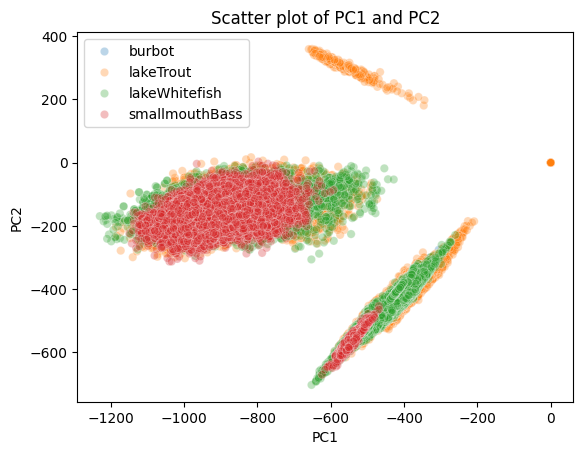

In [50]:
## Plot the Scatter plot of the first 2 PCs
scatterStart = time.time()
plt.Figure(figsize=(8, 6))
sns.scatterplot(x=Z_hat.iloc[:, 0], y=Z_hat.iloc[:, 1], hue=identifiers["species"], alpha=0.3)
plt.title('Scatter plot of PC1 and PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.savefig(os.path.join(newResultDir, "Scatter plot of PC1 and PC2.png"), dpi=300)
plt.show()
scatterEnd = time.time()
scatterTime = scatterEnd - scatterStart

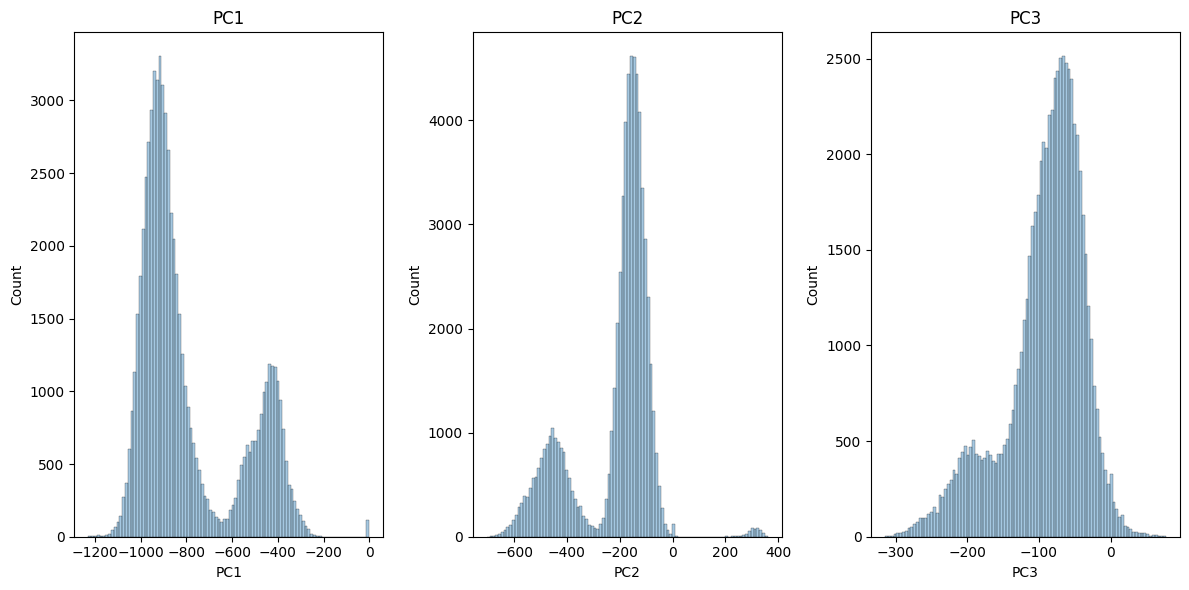

In [9]:
## Visualize the marginal distribution of the first 3 PCs
Z_hat["species"] = identifiers["species"]
hue="species",
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.histplot(Z_hat.iloc[:, 0], bins=100, alpha=0.4)
plt.title('PC1')
plt.subplot(1, 3, 2)
sns.histplot(Z_hat.iloc[:, 1], bins=100, alpha=0.4)
plt.title('PC2')
plt.subplot(1, 3, 3)
sns.histplot(Z_hat.iloc[:, 2], bins=100, alpha=0.4)
plt.title('PC3')
plt.tight_layout()
plt.savefig(newResultDir + "PC-Projections-of-Raw-Data.png")
plt.show()
Z_hat.drop(columns=["species"], inplace=True)



# Compare Stacked Spectrograms before and after PCA

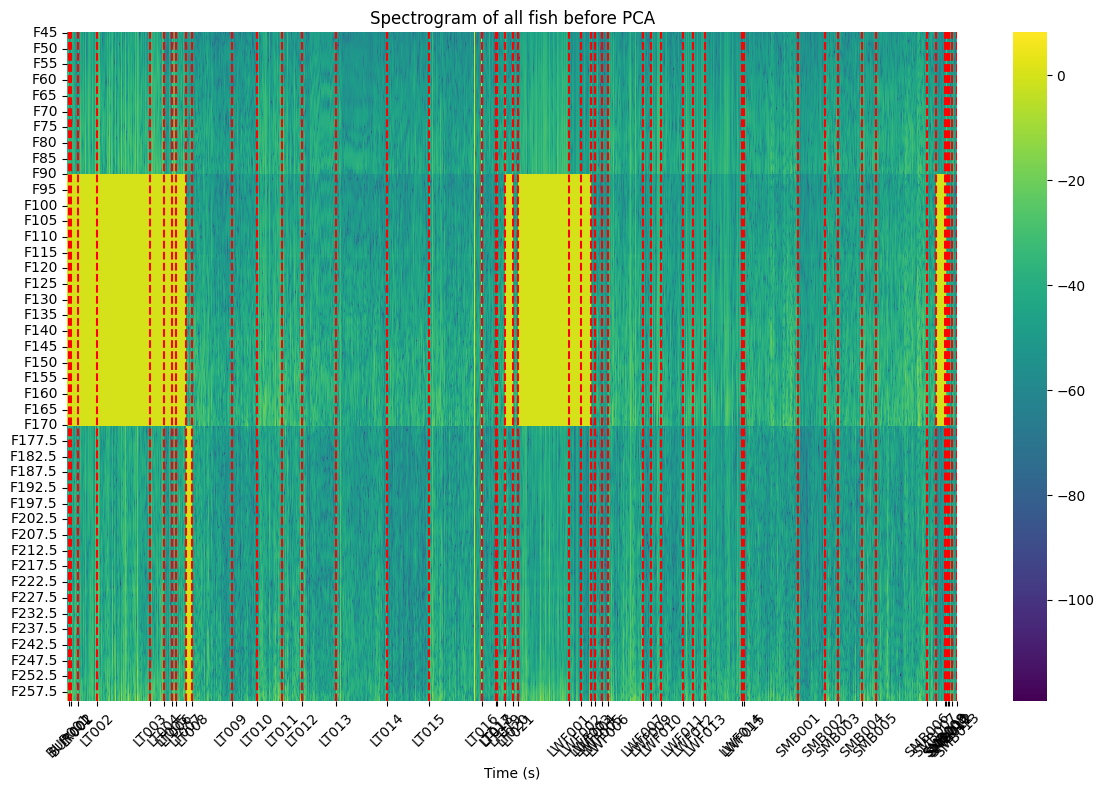

<Figure size 640x480 with 0 Axes>

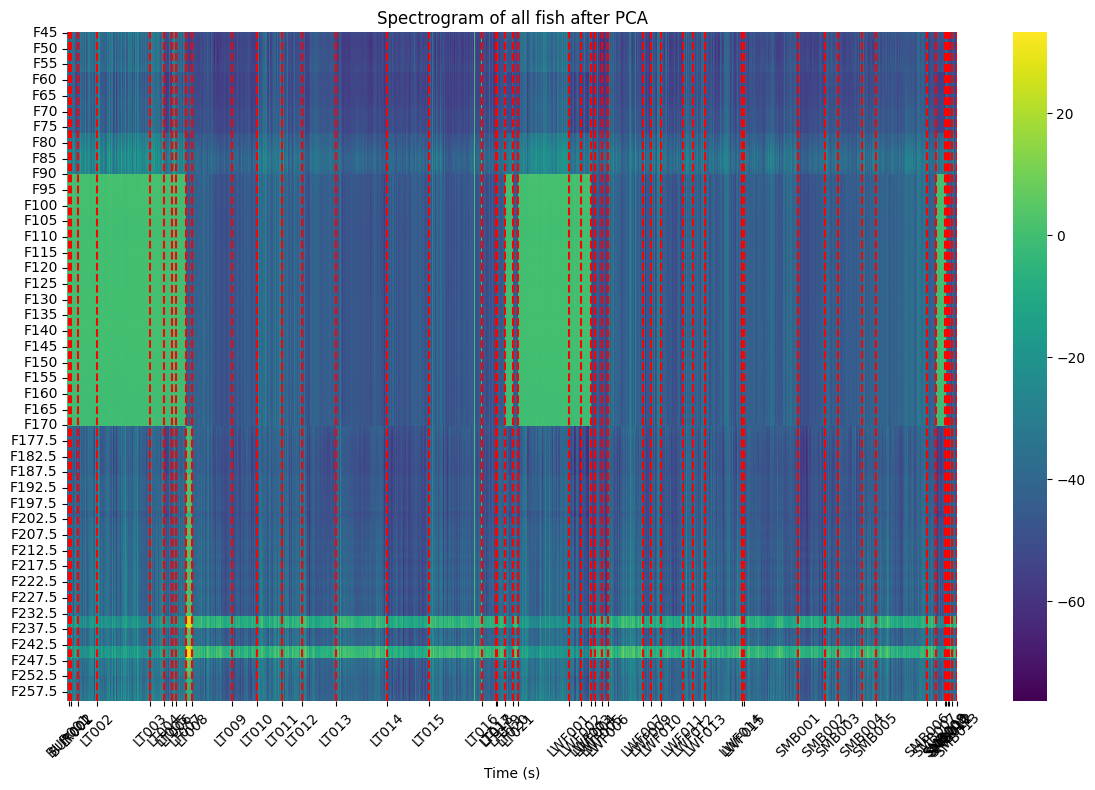

Spectrogram time: 83.21 seconds


<Figure size 640x480 with 0 Axes>

In [55]:
specStart = time.time()
X_hat = pd.DataFrame(np.dot(Z_hat, V_hard.T), columns=X.columns)
cumLengths = np.cumsum(lengthsByFish)
fishList = identifiers["fishNum"].unique()

spectrogram(X, cumLengths, fishList,\
            saveFig=True, title="Spectrogram of all fish before PCA",
            outputPath=newResultDir)

spectrogram(X_hat, cumLengths, fishList, \
            saveFig=True, title="Spectrogram of all fish after PCA",\
            outputPath=newResultDir)
specEnd = time.time()
specTime = specEnd - specStart
print(f"Spectrogram time: {specTime:.2f} seconds")


# HMM State Prediction

In [17]:
# Perform HMM on the Z_hat data
hmmStart = time.time()
hmmResult = performHMM(Z_hat, lengthsByFish, newResultDir)
hmmPredStates = hmmResult["predStates"]
hmmEnd = time.time()
hmmTime = hmmEnd - hmmStart
print(f"HMM time: {hmmTime:.2f} seconds")

HMM parameters of HMM: 30 score features, Gaussian Mixture diagonal, before differencing
Intial distributions:     startProb
0   0.000316
1   0.246807
2   0.300000
3   0.452877 

Transition matrix:     transMat_0  transMat_1  transMat_2  transMat_3
0    0.062263    0.936362    0.001324    0.000051
1    0.970043    0.000024    0.002353    0.027580
2    0.000031    0.004007    0.995543    0.000418
3    0.000011    0.035955    0.000303    0.963732 

Goodness of fit: 

BIC: 617085.4117218456 

AIC: 615964.0530470277 

HMM time: 61.99 seconds


In [30]:
print("Mean vector of each state:")
pd.DataFrame(hmmResult["means"].T)

Mean vector of each state:


,0,1,2,3
0,-0.696970,-0.688253,1.630810,-0.026371
1,0.450888,0.450966,-1.597436,0.612914
2,0.322026,0.326398,-1.239919,0.542374
3,-0.027516,-0.021234,-0.098895,0.172972
4,-0.026461,-0.023042,0.041019,0.018316
5,-0.056134,-0.053870,-0.032595,0.178176


In [31]:
## Diagonal elements of covariance matrix
covarArray = hmmResult["Covars"]
diagCovars = np.array([np.diag(cov) for cov in covarArray])
diagCovars = pd.DataFrame(diagCovars.T, columns = [f"state {i}" for i in range(4)])
print(diagCovars)

    state 0   state 1   state 2   state 3
0  0.070797  0.072901  0.132248  0.163621
1  0.079923  0.080587  0.308508  0.404015
2  0.241253  0.245803  0.808255  0.890061
3  0.799486  0.843787  1.167026  1.232999
4  0.899209  0.912384  1.141282  1.082412
5  0.813063  0.865364  1.295344  1.046773


# State-Species Assignment

In [ ]:
assignStart = time.time()
speciesList = ['burbot', 'laketrout', 'lakeWhitefish', 'smallmouthBass']
assignResult = permuteSpecies(hmmPredStates, speciesList, identifiers, newResultDir)
assignEnd = time.time()
assignTime = assignEnd - assignStart
print(f"Species assignment time: {assignTime:.2f} seconds")

C:\Users\86139\AppData\Local\Temp\ipykernel_20096\2384630750.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  accSmry = pd.concat([accSmry, newRes], ignore_index=True)


The Best State-Species mapping:  {2: 'burbot', 0: 'laketrout', 3: 'lakeWhitefish', 1: 'smallmouthBass'}
Accuracy:  32.0 %

Species assignment time: 1.29 seconds


C:\Users\86139\AppData\Local\Temp\ipykernel_20096\2384630750.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("The Best State-Species mapping: ", bestPerm[0])
C:\Users\86139\AppData\Local\Temp\ipykernel_20096\2384630750.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Accuracy: ", round(bestPerm[1]*100, 2), "%\n")


Text(0.5, 0, 'Fish Number')

<Figure size 1200x600 with 0 Axes>

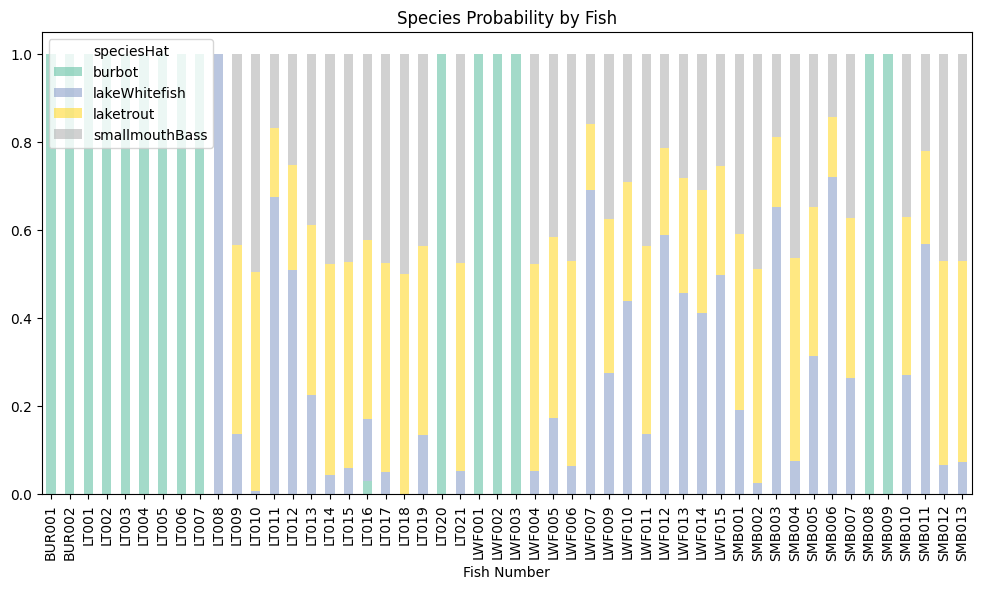

In [47]:
## Visualize probability of each species in each fish
speciesProp = assignResult["speciesProp"]
plt.figure(figsize=(12, 6))
speciesProp.set_index("fishNum")[["burbot", "lakeWhitefish", "laketrout", "smallmouthBass"]].plot(
    kind="bar", stacked=True, figsize=(12, 6), colormap="Set2", alpha=0.6
)
plt.title("Species Probability by Fish")
plt.xlabel("Fish Number")

In [51]:
timeReport = pd.DataFrame({
    "Step": ["Reading Data", "PCA", "Scatter Plot", "HMM", "Permutation"],
    "Time (s)": [readingTime, pcaTime, scatterTime, hmmTime, assignTime]
})
timeReport.to_csv(os.path.join(newResultDir, "TimeReport.csv"), index=False)
timeReport

,Step,Time (s)
0,Reading Data,42.748437
1,PCA,1.620358
2,Scatter Plot,7.508686
3,HMM,61.985080
4,Permutation,1.285587
